In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [23]:

# INCEPTION V3 — 299×299 native

inception_train_transforms = T.Compose([
    T.Resize((320, 320)),               # Resize slightly larger than target
    T.RandomCrop((299, 299)),           # Random crop to native size — more variety than center
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),       # Small rotation — pets naturally tilt heads
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),
    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.1, scale=(0.02, 0.08), ratio=(0.3, 3.3))
])

inception_eval_transforms = T.Compose([
    T.Resize((320, 320)),
    T.CenterCrop((299, 299)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# DENSENET 121 — 224×224 native
densenet_train_transforms = T.Compose([
    T.Resize((256, 256)),               # Resize to 256 (DenseNet standard)
    T.RandomCrop((224, 224)),           # Random crop to native size
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.1,
        hue=0.05
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

densenet_eval_transforms = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop((224, 224)),           # Standard DenseNet eval protocol
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_dataset_INCEPTION = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/train', transform=inception_train_transforms)
val_dataset_INCEPTION = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/valid', transform=inception_eval_transforms)
test_dataset_INCEPTION = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/test', transform=inception_eval_transforms)

train_dataset_DENSENET = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/train', transform=densenet_train_transforms)
val_dataset_DENSENET = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/valid', transform=densenet_eval_transforms)
test_dataset_DENSENET = datasets.ImageFolder(root='/content/drive/MyDrive/Master Folder/test', transform=densenet_eval_transforms)




train_loader_INCEPTION = DataLoader(train_dataset_INCEPTION, batch_size=32, shuffle=True, num_workers=2)
val_loader_INCEPTION = DataLoader(val_dataset_INCEPTION, batch_size=32, shuffle=False, num_workers=2)
test_loader_INCEPTION = DataLoader(test_dataset_INCEPTION, batch_size=32, shuffle=False, num_workers=2)



train_loader_DENSENET = DataLoader(train_dataset_DENSENET, batch_size=32, shuffle=True, num_workers=2)
val_loader_DENSENET = DataLoader(val_dataset_DENSENET, batch_size=32, shuffle=False, num_workers=2)
test_loader_DENSENET = DataLoader(test_dataset_DENSENET, batch_size=32, shuffle=False, num_workers=2)

In [24]:
num_classes = len(train_dataset_INCEPTION.classes)
print(f"Dataset sizes:")
print(f"  Training samples: {len(train_dataset_INCEPTION)}")
print(f"  Validation samples: {len(val_dataset_INCEPTION)}")
print(f"  Test samples: {len(test_dataset_INCEPTION)}")

print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset_INCEPTION.classes}")

Dataset sizes:
  Training samples: 1000
  Validation samples: 36
  Test samples: 38
Number of classes: 4
Classes: ['Angry', 'Other', 'Sad', 'happy']


## training
Trains the model for one complete pass through the training dataset, updating model weights via backpropagation.

### Parameters:
- `model`: The neural network to train
- `train_load`: DataLoader containing training batches
- `criterion`: Loss function (e.g., CrossEntropyLoss)
- `optimizer`: Optimization algorithm (e.g., Adam, SGD)
- `device`: Computation device (CPU or CUDA)
### Returns:
- `train_loss`: Average loss per batch for the epoch
- `train_acc`: Overall training accuracy percentage for the epoch
### Training Flow:
`Batch Input → Forward Pass → Loss Calculation → Backward Pass → Weight Update → Metrics Accumulation`

In [25]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100. * correct / total

# evaluation
Performs inference on a dataset, calculates performance metrics, and collects predictions for further analysis.

### Parameters:
- `model`: The neural network to evaluate
- `val_loader`: DataLoader containing validation/test batches
- `criterion`: Loss function (same as training)
- `device`: Computation device (CPU or CUDA)
### Returns:
- `val_loss`: Average loss per batch
- `val_acc`: Overall accuracy percentage
- `all_preds`: List of all predicted class indices
- `all_labels`: List of all ground truth labels


In [26]:
def evaluate(model, val_loader, criterion, device):
    model.eval() #Sets model to evaluation mode (disables dropout, uses running stats for batch norm)
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disables gradient computation to save memory and speed up inference
        #Iterates through batches in the DataLoader with progress visualization using `tqdm`.
        for inputs, labels in tqdm(val_loader, desc="Evaluating", leave=False):
            #Forward Pass Only
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            # Metrics & Predictions Tracking
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc, all_preds, all_labels

In [27]:
def plot_confusion_matrix(cm, classes, model_name):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

In [28]:
def train_and_evaluate_model(model_name, model, num_epochs=10, lr=0.001):
    print(f"\n{'='*60}")
    print(f"TRAINING AND EVALUATING: {model_name}")
    print(f"{'='*60}")

    # Select appropriate loaders and datasets based on model name
    if "InceptionV3" in model_name:
        train_loader = train_loader_INCEPTION
        val_loader = val_loader_INCEPTION
        test_loader = test_loader_INCEPTION
        current_train_ds = train_dataset_INCEPTION
        current_test_ds = test_dataset_INCEPTION
    else:
        train_loader = train_loader_DENSENET
        val_loader = val_loader_DENSENET
        test_loader = test_loader_DENSENET
        current_train_ds = train_dataset_DENSENET
        current_test_ds = test_dataset_DENSENET

    model = model.to(device)

    # Calculate class weights for imbalanced datasets
    class_counts = torch.zeros(num_classes)
    for _, label in current_train_ds:
        class_counts[label] += 1

    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * num_classes
    class_weights = class_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=1,
        eta_min=1e-6
    )

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print(f"  Current LR: {current_lr:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, f'best_{model_name.replace(" ", "_")}.pth')
            print(f"  --> Best model saved with Val Loss: {val_loss:.4f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\n{'='*60}")
    print(f"FINAL TEST EVALUATION - {model_name}")
    print(f"{'='*60}")

    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average='macro')

    print(f"TEST Accuracy: {test_acc:.2f}%")
    print(f"TEST F1-Score: {f1:.4f}")
    print(f"\nTEST Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=current_test_ds.classes))

    test_cm = confusion_matrix(test_labels, test_preds)
    plot_confusion_matrix(test_cm, current_test_ds.classes, f"{model_name} (Test)")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_title('Loss Curves')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.2f}%')
    ax2.set_title('Accuracy Curves')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        'model_name': model_name,
        'test_accuracy': test_acc,
        'test_f1_score': f1
    }

## Inception V3 Architecture

The **Inception v3** architecture optimizes deep convolutional networks by using **factorized, multi-scale feature extraction**. Instead of using a single generic block layout, it deploys specialized Inception modules tailored to specific spatial dimensions to drastically reduce parameters while maximizing information flow.

### Key Structural Blocks

* **Convolutional Stem:** A deep sequence of initial layers that aggressively downsamples raw inputs from **$299 \times 299 \times 3$** to a compact **$35 \times 35 \times 192$** feature map before it reaches the main blocks.
* **InceptionA ($35 \times 35$ Grid):** Replaces large $5 \times 5$ convolutions with two stacked, efficient $3 \times 3$ layers.
* **InceptionC ($17 \times 17$ Grid):** Introduces **asymmetric convolutions** (factorizing $7 \times 7$ layers into parallel $1 \times 7$ and $7 \times 1$ sequences) to cut parameter weight by nearly 33%.
* **InceptionE ($8 \times 8$ Grid):** Uses parallelized asymmetric branches that split wide channels laterally to synthesize high-level semantic features.
* **Grid Reduction Blocks (B & D):** Specialized modules that run pooling and strided convolutions concurrently to prevent data loss or architectural bottlenecks during downsampling.

### Network Flow Summary

* **Spatial Downsampling:** $299 \times 299 \rightarrow 149 \times 149 \rightarrow 147 \times 147 \rightarrow 73 \times 73 \rightarrow 71 \times 71 \rightarrow 35 \times 35 \rightarrow 17 \times 17 \rightarrow 8 \times 8 \rightarrow 1 \times 1$
* **Channel Expansion:** $3 \rightarrow 32 \rightarrow 64 \rightarrow 80 \rightarrow 192 \rightarrow 288 \rightarrow 768 \rightarrow 1280 \rightarrow 2048$
* **Classifier Head:** Employs Adaptive Average Pooling, $50\%$ Dropout, and a final Linear layer ($2048 \rightarrow \text{num\_classes}$).

---

In [29]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        # Inception v3 omits bias in conv layers because BatchNorm handles it
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

In [30]:
class InceptionA(nn.Module):
    # Used for the 35x35 grid
    def __init__(self, in_channels, pool_features):
        super(InceptionA, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 64, kernel_size=1)

        self.branch5x5_1 = BasicConv2d(in_channels, 48, kernel_size=1)
        self.branch5x5_2 = BasicConv2d(48, 64, kernel_size=5, padding=2)

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, padding=1)

        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, pool_features, kernel_size=1)
        )

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch5x5 = self.branch5x5_2(self.branch5x5_1(x))
        branch3x3dbl = self.branch3x3dbl_3(self.branch3x3dbl_2(self.branch3x3dbl_1(x)))
        branch_pool = self.branch_pool(x)

        outputs = [branch1x1, branch5x5, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)

In [31]:
class InceptionB(nn.Module):
    # Reduction block (35x35 -> 17x17)
    def __init__(self, in_channels):
        super(InceptionB, self).__init__()
        self.branch3x3 = BasicConv2d(in_channels, 384, kernel_size=3, stride=2)

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 64, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(64, 96, kernel_size=3, padding=1)
        self.branch3x3dbl_3 = BasicConv2d(96, 96, kernel_size=3, stride=2)

        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x):
        branch3x3 = self.branch3x3(x)
        branch3x3dbl = self.branch3x3dbl_3(self.branch3x3dbl_2(self.branch3x3dbl_1(x)))
        branch_pool = self.branch_pool(x)

        outputs = [branch3x3, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)

In [32]:
class InceptionC(nn.Module):
    # Used for the 17x17 grid (features asymmetric convolutions)
    def __init__(self, in_channels, channels_7x7):
        super(InceptionC, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 192, kernel_size=1)

        c7 = channels_7x7
        self.branch7x7_1 = BasicConv2d(in_channels, c7, kernel_size=1)
        self.branch7x7_2 = BasicConv2d(c7, c7, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7_3 = BasicConv2d(c7, 192, kernel_size=(7, 1), padding=(3, 0))

        self.branch7x7dbl_1 = BasicConv2d(in_channels, c7, kernel_size=1)
        self.branch7x7dbl_2 = BasicConv2d(c7, c7, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_3 = BasicConv2d(c7, c7, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7dbl_4 = BasicConv2d(c7, c7, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7dbl_5 = BasicConv2d(c7, 192, kernel_size=(1, 7), padding=(0, 3))

        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, 192, kernel_size=1)
        )

    def forward(self, x):
        branch1x1 = self.branch1x1(x)
        branch7x7 = self.branch7x7_3(self.branch7x7_2(self.branch7x7_1(x)))
        branch7x7dbl = self.branch7x7dbl_5(self.branch7x7dbl_4(self.branch7x7dbl_3(
            self.branch7x7dbl_2(self.branch7x7dbl_1(x)))))
        branch_pool = self.branch_pool(x)

        outputs = [branch1x1, branch7x7, branch7x7dbl, branch_pool]
        return torch.cat(outputs, 1)

In [33]:
class InceptionD(nn.Module):
    # Reduction block (17x17 -> 8x8)
    def __init__(self, in_channels):
        super(InceptionD, self).__init__()
        self.branch3x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch3x3_2 = BasicConv2d(192, 320, kernel_size=3, stride=2)

        self.branch7x7x3_1 = BasicConv2d(in_channels, 192, kernel_size=1)
        self.branch7x7x3_2 = BasicConv2d(192, 192, kernel_size=(1, 7), padding=(0, 3))
        self.branch7x7x3_3 = BasicConv2d(192, 192, kernel_size=(7, 1), padding=(3, 0))
        self.branch7x7x3_4 = BasicConv2d(192, 192, kernel_size=3, stride=2)

        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x):
        branch3x3 = self.branch3x3_2(self.branch3x3_1(x))
        branch7x7x3 = self.branch7x7x3_4(self.branch7x7x3_3(
            self.branch7x7x3_2(self.branch7x7x3_1(x))))
        branch_pool = self.branch_pool(x)

        outputs = [branch3x3, branch7x7x3, branch_pool]
        return torch.cat(outputs, 1)

In [34]:
class InceptionE(nn.Module):
    # Used for the 8x8 grid (features expanded filter banks)
    def __init__(self, in_channels):
        super(InceptionE, self).__init__()
        self.branch1x1 = BasicConv2d(in_channels, 320, kernel_size=1)

        self.branch3x3_1 = BasicConv2d(in_channels, 384, kernel_size=1)
        self.branch3x3_2a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3_2b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        self.branch3x3dbl_1 = BasicConv2d(in_channels, 448, kernel_size=1)
        self.branch3x3dbl_2 = BasicConv2d(448, 384, kernel_size=3, padding=1)
        self.branch3x3dbl_3a = BasicConv2d(384, 384, kernel_size=(1, 3), padding=(0, 1))
        self.branch3x3dbl_3b = BasicConv2d(384, 384, kernel_size=(3, 1), padding=(1, 0))

        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv2d(in_channels, 192, kernel_size=1)
        )

    def forward(self, x):
        branch1x1 = self.branch1x1(x)

        branch3x3 = self.branch3x3_1(x)
        branch3x3 = torch.cat([
            self.branch3x3_2a(branch3x3),
            self.branch3x3_2b(branch3x3),
        ], 1)

        branch3x3dbl = self.branch3x3dbl_2(self.branch3x3dbl_1(x))
        branch3x3dbl = torch.cat([
            self.branch3x3dbl_3a(branch3x3dbl),
            self.branch3x3dbl_3b(branch3x3dbl),
        ], 1)

        branch_pool = self.branch_pool(x)

        outputs = [branch1x1, branch3x3, branch3x3dbl, branch_pool]
        return torch.cat(outputs, 1)

In [35]:
class InceptionV3(nn.Module):
    def __init__(self, num_classes=1000, dropout=0.5):
        super(InceptionV3, self).__init__()

        # Stem
        self.Conv2d_1a_3x3 = BasicConv2d(3, 32, kernel_size=3, stride=2)
        self.Conv2d_2a_3x3 = BasicConv2d(32, 32, kernel_size=3)
        self.Conv2d_2b_3x3 = BasicConv2d(32, 64, kernel_size=3, padding=1)
        self.maxpool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.Conv2d_3b_1x1 = BasicConv2d(64, 80, kernel_size=1)
        self.Conv2d_4a_3x3 = BasicConv2d(80, 192, kernel_size=3)
        self.maxpool2 = nn.MaxPool2d(kernel_size=3, stride=2)

        # Inception Blocks
        self.Mixed_5b = InceptionA(192, pool_features=32)
        self.Mixed_5c = InceptionA(256, pool_features=64)
        self.Mixed_5d = InceptionA(288, pool_features=64)

        self.Mixed_6a = InceptionB(288)

        self.Mixed_6b = InceptionC(768, channels_7x7=128)
        self.Mixed_6c = InceptionC(768, channels_7x7=160)
        self.Mixed_6d = InceptionC(768, channels_7x7=160)
        self.Mixed_6e = InceptionC(768, channels_7x7=192)

        self.Mixed_7a = InceptionD(768)

        self.Mixed_7b = InceptionE(1280)
        self.Mixed_7c = InceptionE(2048)

        # Output layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Linear(2048, num_classes)

    def forward(self, x):
        # N x 3 x 299 x 299 (Standard Inception v3 Input Size)
        x = self.Conv2d_1a_3x3(x)
        x = self.Conv2d_2a_3x3(x)
        x = self.Conv2d_2b_3x3(x)
        x = self.maxpool1(x)

        x = self.Conv2d_3b_1x1(x)
        x = self.Conv2d_4a_3x3(x)
        x = self.maxpool2(x)

        x = self.Mixed_5b(x)
        x = self.Mixed_5c(x)
        x = self.Mixed_5d(x)

        x = self.Mixed_6a(x)

        x = self.Mixed_6b(x)
        x = self.Mixed_6c(x)
        x = self.Mixed_6d(x)
        x = self.Mixed_6e(x)

        x = self.Mixed_7a(x)

        x = self.Mixed_7b(x)
        x = self.Mixed_7c(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        return x


TRAINING AND EVALUATING: InceptionV3

Epoch 1/20


  Train Loss: 1.4456 | Train Acc: 26.70%
  Val Loss: 1.3741 | Val Acc: 30.56%
  Current LR: 0.000976
  --> Best model saved with Val Loss: 1.3741

Epoch 2/20


  Train Loss: 1.4313 | Train Acc: 26.90%
  Val Loss: 1.3571 | Val Acc: 27.78%
  Current LR: 0.000905
  --> Best model saved with Val Loss: 1.3571

Epoch 3/20


  Train Loss: 1.4038 | Train Acc: 27.10%
  Val Loss: 14.4209 | Val Acc: 27.78%
  Current LR: 0.000794

Epoch 4/20


  Train Loss: 1.4171 | Train Acc: 26.60%
  Val Loss: 1.2965 | Val Acc: 33.33%
  Current LR: 0.000655
  --> Best model saved with Val Loss: 1.2965

Epoch 5/20


...

  Train Loss: 1.3390 | Train Acc: 35.40%
  Val Loss: 1.4423 | Val Acc: 27.78%
  Current LR: 0.000207

Epoch 18/20


  Train Loss: 1.3289 | Train Acc: 37.60%
  Val Loss: 1.2571 | Val Acc: 33.33%
  Current LR: 0.000096
  --> Best model saved with Val Loss: 1.2571

Epoch 19/20


  Train Loss: 1.3118 | Train Acc: 41.00%
  Val Loss: 1.2210 | Val Acc: 30.56%
  Current LR: 0.000025
  --> Best model saved with Val Loss: 1.2210

Epoch 20/20


  Train Loss: 1.2981 | Train Acc: 39.80%
  Val Loss: 1.2222 | Val Acc: 33.33%
  Current LR: 0.001000

FINAL TEST EVALUATION - InceptionV3


TEST Accuracy: 36.84%
TEST F1-Score: 0.3647

TEST Classification Report:
              precision    recall  f1-score   support

       Angry       0.38      0.30      0.33        10
       Other       0.43      0.50      0.46         6
         Sad       0.33      0.18      0.24        11
       happy       0.35      0.55      0.43        11

    accuracy                           0.37        38
   macro avg       0.37      0.38      0.36        38
weighted avg       0.37      0.37      0.35        38



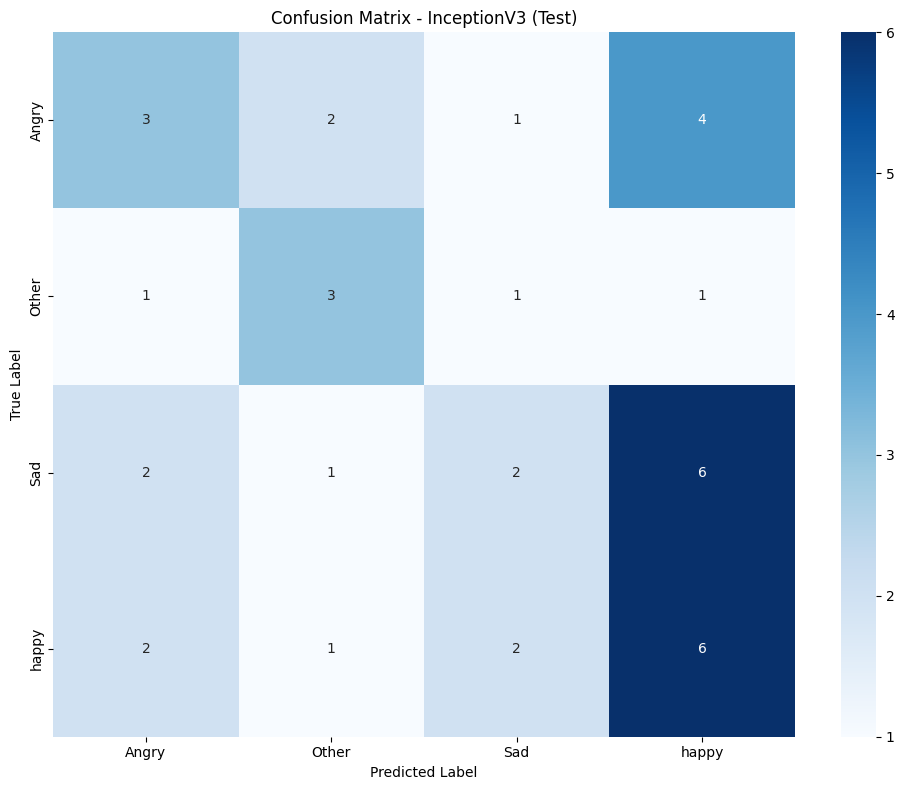

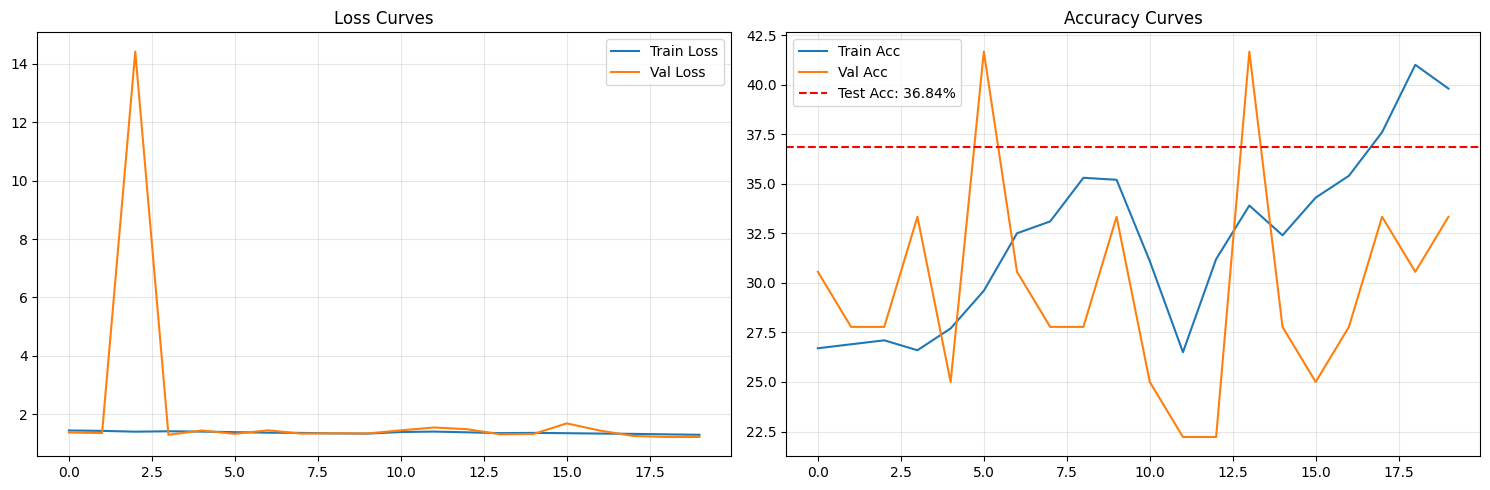

In [36]:
inception_model = InceptionV3(num_classes=num_classes)
inception_results = train_and_evaluate_model("InceptionV3", inception_model, num_epochs=18, lr=0.001)

## DenseNet121

### DenseNet121 Implementation

The DenseNet121 architecture introduces the concept of **dense connectivity**, where each layer receives the feature maps of all preceding layers as input. This connectivity pattern promotes extensive feature reuse, improves gradient propagation, and significantly enhances parameter efficiency.

---

## DenseLayer Class

The `DenseLayer` serves as the fundamental building block of DenseNet and implements the dense connection mechanism.

### Layer Structure

` Input (concatenated feature maps from previous layers) `
` → BatchNorm `
` → ReLU `
` → 1×1 Convolution (Bottleneck: 4 × growth_rate) `
` → BatchNorm `
` → ReLU `
` → 3×3 Convolution (growth_rate feature maps) `
` → Concatenate output with input `

Instead of replacing previous feature maps, each layer appends newly generated features to the existing feature set.

---

### Growth Rate (`k`)

The **growth rate** determines how many new feature maps each DenseLayer contributes to the network.

* Typical value: `k = 32`
* Controls the expansion speed of channel dimensions
* Smaller growth rates improve parameter efficiency

---

### Bottleneck Layer

A `1×1` convolution is used before the `3×3` convolution to reduce the number of input channels and decrease computational cost.

This bottleneck design enables DenseNet to remain computationally efficient despite dense feature concatenation.

---

## DenseBlock Class

A `DenseBlock` consists of multiple DenseLayers connected densely together.

Within a block:

* Each layer receives the outputs of **all previous layers**
* Feature maps are continuously concatenated
* Information and gradients flow directly across the network

This connectivity pattern encourages the learning of complementary rather than redundant features.

---

## TransitionLayer Class

The `TransitionLayer` is responsible for reducing feature-map size and controlling model complexity between DenseBlocks.

### Structure

`Input`
`→ BatchNorm`
`→ ReLU`
`→ 1×1 Convolution (compression)`
`→ 2×2 Average Pooling`

---

### Compression

Transition layers typically reduce the number of channels using a compression factor:

`θ = 0.5`

This helps prevent excessive growth in memory and computation caused by repeated concatenations.

---

# DenseNet121 Architecture

## Initial Layers

The network begins with a standard convolutional stem:

* `7×7` convolution with stride `2`
* Batch Normalization + ReLU activation
* `3×3` max pooling with stride `2`

Spatial resolution progression:

`224×224 → 112×112 → 56×56`

---

## Dense Blocks and Transition Layers

### Dense Block 1

* `6` DenseLayers
* `growth_rate = 32`

Output channels:

`64 + (6 × 32) = 256`

#### Transition 1

* Compresses channels to `128`
* Downsamples feature maps to `28×28`

---

### Dense Block 2

* `12` DenseLayers
* `growth_rate = 32`

Output channels:

`128 + (12 × 32) = 512`

#### Transition 2

* Compresses channels to `256`
* Downsamples feature maps to `14×14`

---

### Dense Block 3

* `24` DenseLayers
* `growth_rate = 32`

Output channels:

`256 + (24 × 32) = 1024`

#### Transition 3

* Compresses channels to `512`
* Downsamples feature maps to `7×7`

---

### Dense Block 4

* `16` DenseLayers
* `growth_rate = 32`

Output channels:

`512 + (16 × 32) = 1024`

---

## Final Classifier

The classification head consists of:

`BatchNorm → ReLU → Global Average Pooling → Fully Connected Layer`

Global average pooling reduces each feature map to a single value, creating a compact representation before classification.

---

# Key Design Principles

## Feature Reuse

Dense connectivity enables every layer to access all previously learned feature maps.

Benefits include:

* Learning complementary representations
* Reducing redundant feature extraction
* Preserving low-level and high-level information simultaneously

---

## Parameter Efficiency

DenseNet achieves strong performance with relatively few parameters due to:

* Narrow layers (`k = 32`)
* Bottleneck `1×1` convolutions
* Extensive feature reuse instead of relearning similar patterns

Compared to traditional CNNs of similar depth, DenseNet is significantly more parameter-efficient.

---

## Improved Gradient Flow

Direct connections between layers create shorter paths for gradient propagation.

This helps:

* Reduce the vanishing gradient problem
* Improve convergence during training
* Strengthen learning signals throughout the network

---

# Trade-offs

### Advantages

* Excellent parameter efficiency
* Strong gradient propagation
* High classification accuracy
* Effective feature reuse

### Limitations

* Higher GPU memory consumption during training
* Increased memory bandwidth due to feature concatenation
* Slower inference in some implementations because of dense connections


In [37]:
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4 * growth_rate)
        self.conv2 = nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)
        return torch.cat([x, out], 1)

class DenseBlock(nn.Module):
    def __init__(self, in_channels, num_layers, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.bn(x)
        x = self.relu(x)
        x = self.conv(x)
        x = self.pool(x)
        return x

class DenseNet121(nn.Module):
    def __init__(self, num_classes=1000, growth_rate=32):
        super(DenseNet121, self).__init__()

        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Dense blocks
        num_channels = 64
        self.dense1 = DenseBlock(num_channels, 6, growth_rate)
        num_channels += 6 * growth_rate
        self.trans1 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2

        self.dense2 = DenseBlock(num_channels, 12, growth_rate)
        num_channels += 12 * growth_rate
        self.trans2 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2

        self.dense3 = DenseBlock(num_channels, 24, growth_rate)
        num_channels += 24 * growth_rate
        self.trans3 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2

        self.dense4 = DenseBlock(num_channels, 16, growth_rate)
        num_channels += 16 * growth_rate

        # Final layers
        self.bn_final = nn.BatchNorm2d(num_channels)
        self.relu_final = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(num_channels, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.dense1(x)
        x = self.trans1(x)
        x = self.dense2(x)
        x = self.trans2(x)
        x = self.dense3(x)
        x = self.trans3(x)
        x = self.dense4(x)

        x = self.bn_final(x)
        x = self.relu_final(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### Training and Evaluation: DenseNet121
In this section, we instantiate the DenseNet121 model with the appropriate number of classes and run the comprehensive training and evaluation pipeline.


TRAINING AND EVALUATING: DenseNet121

Epoch 1/20


  Train Loss: 1.4426 | Train Acc: 28.10%
  Val Loss: 1.2503 | Val Acc: 36.11%
  Current LR: 0.000976
  --> Best model saved with Val Loss: 1.2503

Epoch 2/20


  Train Loss: 1.3961 | Train Acc: 26.30%
  Val Loss: 1.3241 | Val Acc: 38.89%
  Current LR: 0.000905

Epoch 3/20


  Train Loss: 1.3789 | Train Acc: 31.60%
  Val Loss: 1.3192 | Val Acc: 38.89%
  Current LR: 0.000794

Epoch 4/20


  Train Loss: 1.3686 | Train Acc: 34.90%
  Val Loss: 1.4250 | Val Acc: 22.22%
  Current LR: 0.000655

Epoch 5/20


...

  Train Loss: 1.3312 | Train Acc: 34.20%
  Val Loss: 1.3180 | Val Acc: 38.89%
  Current LR: 0.000207

Epoch 18/20


  Train Loss: 1.3258 | Train Acc: 36.50%
  Val Loss: 1.3464 | Val Acc: 30.56%
  Current LR: 0.000096

Epoch 19/20


  Train Loss: 1.3107 | Train Acc: 37.90%
  Val Loss: 1.2957 | Val Acc: 33.33%
  Current LR: 0.000025

Epoch 20/20


  Train Loss: 1.3019 | Train Acc: 39.90%
  Val Loss: 1.2625 | Val Acc: 38.89%
  Current LR: 0.001000

FINAL TEST EVALUATION - DenseNet121


TEST Accuracy: 36.84%
TEST F1-Score: 0.3456

TEST Classification Report:
              precision    recall  f1-score   support

       Angry       0.31      0.50      0.38        10
       Other       0.20      0.17      0.18         6
         Sad       0.38      0.27      0.32        11
       happy       0.56      0.45      0.50        11

    accuracy                           0.37        38
   macro avg       0.36      0.35      0.35        38
weighted avg       0.38      0.37      0.37        38



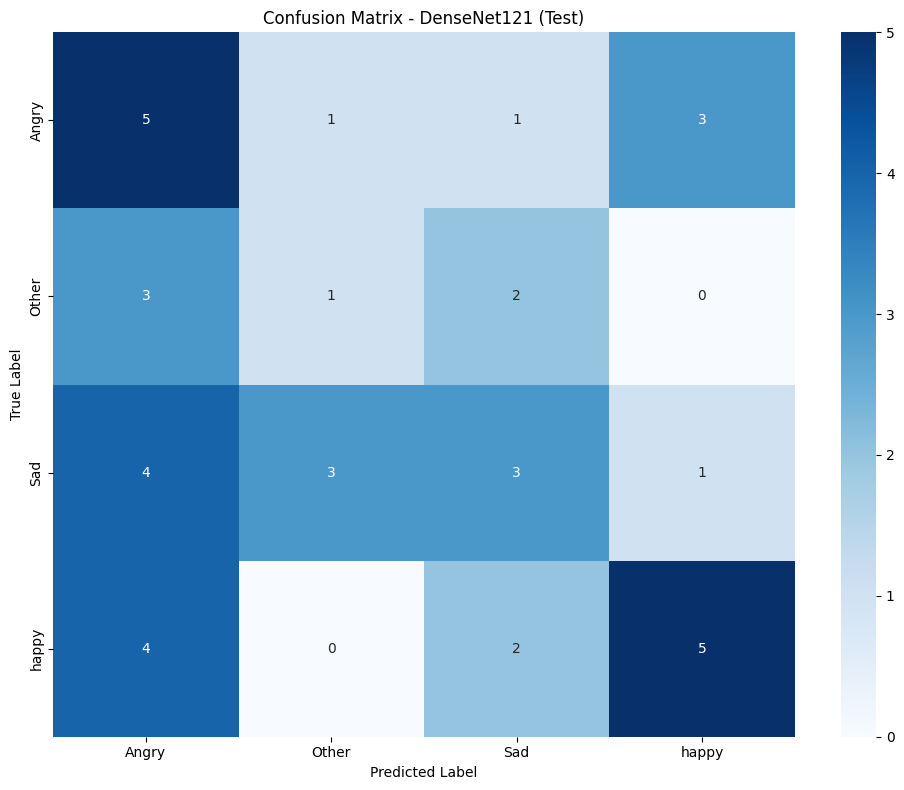

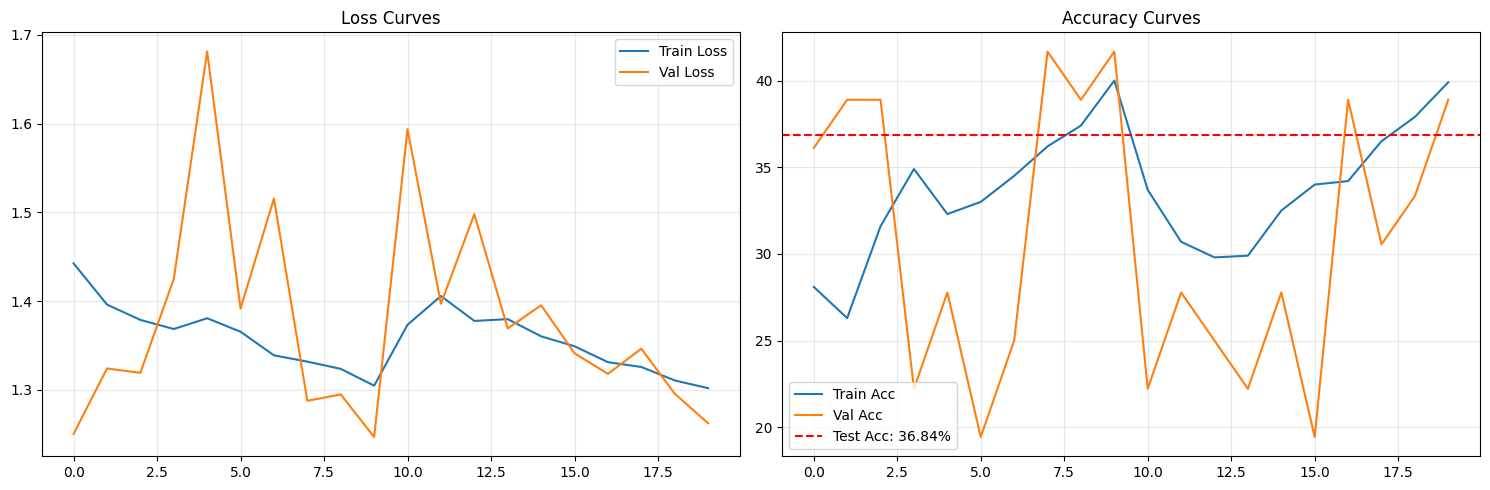

In [38]:
densenet_model = DenseNet121(num_classes=num_classes)
densenet_results = train_and_evaluate_model("DenseNet121", densenet_model, num_epochs=20, lr=0.001)